REPRODUKSI DARI:https://skforecast.org/0.15.1/user_guides/explainability.html

1.Prediksi Tentang Apa?
Pada studi kasus ini dilakukan peramalan (forecasting) terhadap konsumsi listrik (electricity demand) di wilayah Victoria, Australia. Data yang digunakan berupa konsumsi listrik setiap 30 menit selama beberapa tahun.
Tujuan utama model adalah memperkirakan besarnya kebutuhan listrik pada periode berikutnya berdasarkan pola historis konsumsi listrik sebelumnya.
Selain menghasilkan prediksi, penelitian ini juga berfokus pada explainability atau interpretasi model. Oleh karena itu dilakukan analisis untuk mengetahui faktor-faktor yang paling memengaruhi hasil prediksi menggunakan metode Feature Importance, Permutation Importance, SHAP, dan Partial Dependence Plot (PDP).
Secara umum, pertanyaan yang ingin dijawab adalah:
Berapa besar konsumsi listrik pada periode berikutnya?
Faktor historis mana yang paling berpengaruh terhadap prediksi?
Bagaimana setiap fitur memengaruhi kenaikan atau penurunan hasil prediksi?

2.Bentuk Data Training
a. Struktur Data Awal
Dataset awal berbentuk deret waktu (time series) yang terdiri dari waktu pengamatan dan nilai konsumsi listrik.

In [ ]:
Time                 Demand
2011-12-31 13:00     4382.83
2011-12-31 13:30     4263.37
2011-12-31 14:00     4048.97
...                    ...
Kolom Demand merupakan target yang akan diprediks

b.Transformasi Menjadi Supervised Learning
Algoritma machine learning tidak dapat langsung memahami data time series. Oleh karena itu dilakukan transformasi menggunakan metode lag feature.
Pada notebook digunakan:

In [ ]:
lags=24

Artinya model melihat 24 observasi sebelumnya sebagai variabel input.
Karena interval data adalah 30 menit, maka

In [ ]:
24 lag = 12 jam data historis

C.Bentuk Matriks Training



Setelah transformasi, data berubah menjadi:
lag_24     lag_23  ...   lag_2    lag_1  Target
4382        4263   ...    4772     4938   5080


Keterangan:
lag_1 = konsumsi listrik 30 menit sebelumnya
lag_2 = konsumsi listrik 1 jam sebelumnya
lag_24 = konsumsi listrik 12 jam sebelumnya
Target = konsumsi listrik yang akan diprediksi

D.Dimensi Data Training
Hasil notebook menunjukkan:

In [ ]:
X_train = (52584, 24)
y_train = (52584,)

Artinya:
52.584 sampel pelatihan
24 fitur input
1 variabel target
Masalah yang diselesaikan termasuk kategori Supervised Learning Regression karena target berupa nilai numerik kontinu.

3. Konsep Lag dalam Time Series

A.Definisi Lag
Lag merupakan nilai historis dari suatu variabel pada periode sebelumnya yang digunakan sebagai dasar prediksi.
Secara matematis:
dimana:
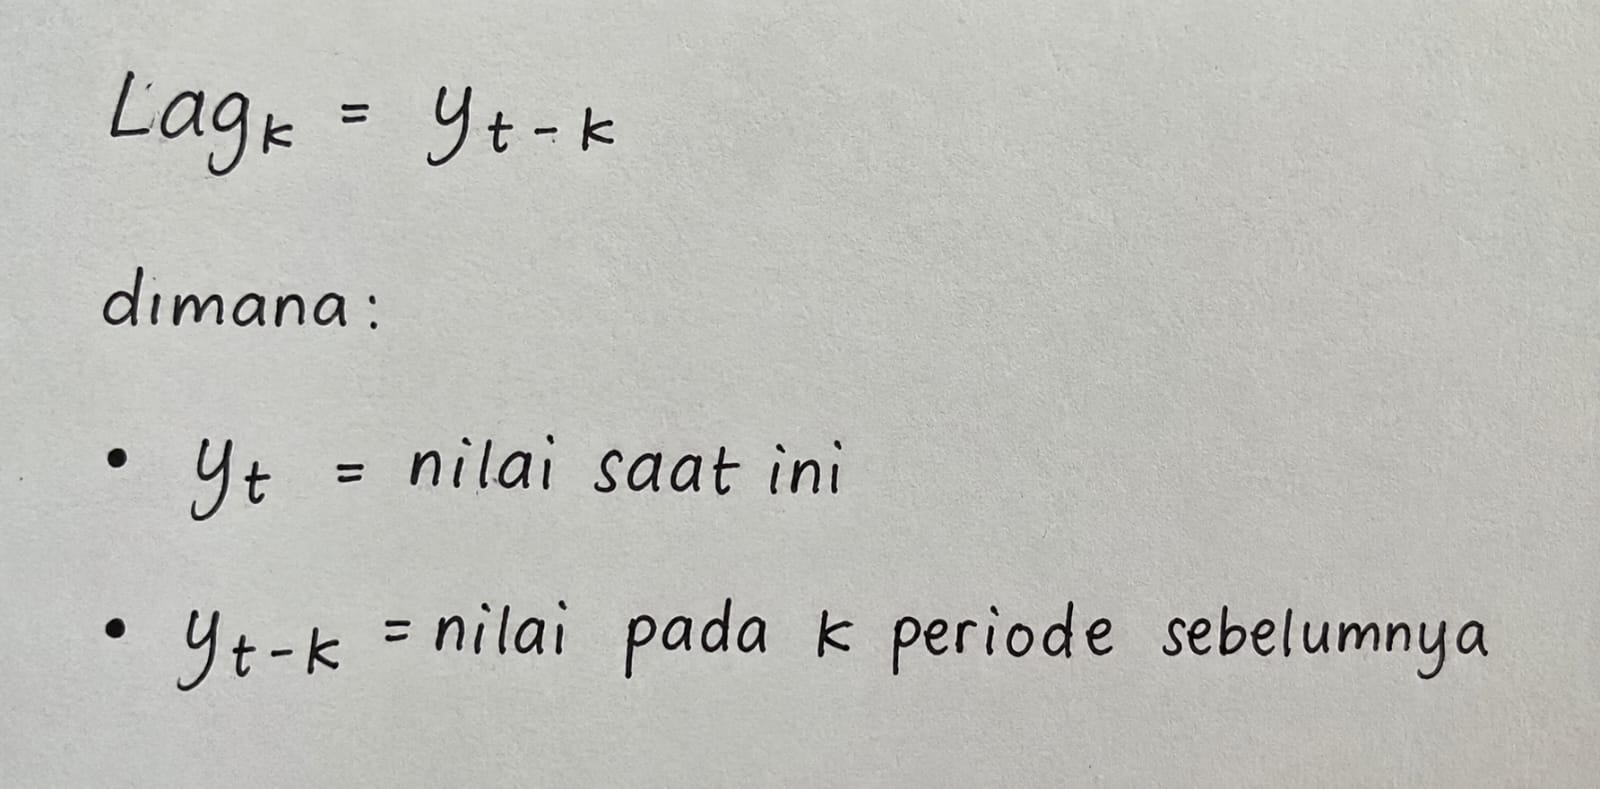

B.Contoh Lag
Misalkan terdapat data:
Waktu  Demand
13:00   4000
13:30   4200
14:00   4500
14:30   4700
Untuk memprediksi pukul 14:30 digunakan:
lag_3
lag_2
lag_1
4000
4200
4500
Target:
4700

C.Fungsi Lag
Lag digunakan untuk menangkap hubungan antar waktu (autocorrelation).
Pada data konsumsi listrik, nilai saat ini sangat dipengaruhi oleh nilai sebelumnya sehingga informasi historis menjadi faktor penting dalam proses prediksi. Konsep penggunaan lag secara luas digunakan dalam forecasting karena pola masa lalu sering mengandung informasi mengenai kondisi masa depan

4. Tahapan Analisis

A.alur keseluruhan
[Data deret waktu vic_electricity]
          │
          ▼
[Transformasi → Matriks lag_1 ... lag_24]
          │
          ▼
[Training: LGBMRegressor via ForecasterRecursive]
          │
    ┌─────┼──────────────────────┐
    ▼     ▼                      ▼
 [6.1]  [6.2]                 [6.3]
Feature  Permutation         SHAP Values
Importance Importance      ┌───┼───┐
                         Summary Bar Force PDP
                          Plot  Plot Plot

B.Feature Importance (Bawaan LightGBM)
Cara paling sederhana. LightGBM menghitung seberapa sering tiap fitur dipakai untuk membelah (split) node di dalam pohon keputusan.




In [ ]:
# Ambil feature importance dari forecaster
feat_imp = forecaster.get_feature_importances()
print(feat_imp.head(10))

Hasilnya biasanya:

lag_1 = skor tertinggi (nilai 30 menit lalu paling sering dipakai)

Semakin besar lag → semakin kecil skornya

Kelemahan: Hanya menunjukkan frekuensi pemakaian, bukan seberapa besar dampaknya pada prediksi.

d. SHAP Values(Teknik Paling Canggih)
SHAP = SHapley Additive exPlanations. Berasal dari teori permainan (game theory) — konsep Shapley value yang menghitung kontribusi adil tiap “pemain” dalam sebuah koalisi.

Ide utamanya: Setiap prediksi
 bisa dipecah-pecah menjadi kontribusi masing-masing fitur:

Proses instal library

In [24]:
from skforecast.datasets import fetch_dataset

In [25]:
# Download data
# ==============================================================================
data = fetch_dataset(name="vic_electricity")
data.head(3)

vic_electricity
---------------
Half-hourly electricity demand for Victoria, Australia
O'Hara-Wild M, Hyndman R, Wang E, Godahewa R (2022).tsibbledata: Diverse
Datasets for 'tsibble'. https://tsibbledata.tidyverts.org/,
https://github.com/tidyverts/tsibbledata/.
https://tsibbledata.tidyverts.org/reference/vic_elec.html
Shape of the dataset: (52608, 4)


,Demand,Temperature,Date,Holiday
Time,,,,
2011-12-31 13:00:00,4382.825174,21.40,2012-01-01,True
2011-12-31 13:30:00,4263.365526,21.05,2012-01-01,True
2011-12-31 14:00:00,4048.966046,20.70,2012-01-01,True


In [4]:
# Install semua library yang dibutuhkan
# Jalankan cell ini hanya sekali, lalu restart runtime jika diminta
!pip install skforecast lightgbm shap --quiet
print("✅ Semua library berhasil diinstall!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 467.3/467.3 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 23.0 MB/s eta 0:00:00
✅ Semua library berhasil diinstall!


import library

In [5]:
# ============================================================================
# Import semua library dan modul spesifik yang digunakan
# ============================================================================
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

import shap
from sklearn.inspection import permutation_importance
from sklearn.inspection import PartialDependenceDisplay
from lightgbm import LGBMRegressor

# Library utama untuk peramalan deret waktu
from skforecast.datasets import fetch_dataset
from skforecast.recursive import ForecasterRecursive

# Mengatur tampilan grafik agar rapi
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

print("✅ Semua library berhasil di-import dan siap digunakan!")

✅ Semua library berhasil di-import dan siap digunakan!


load dan eksplorasi

In [6]:
# Load dataset vic_electricity
data_raw = fetch_dataset('vic_electricity', raw=True)
print("📋 Bentuk data asli:", data_raw.shape)
print()
data_raw.head()

╭──────────────────────────── vic_electricity ─────────────────────────────╮
│ Description:                                                             │
│ Half-hourly electricity demand for Victoria, Australia                   │
│                                                                          │
│ Source:                                                                  │
│ O'Hara-Wild M, Hyndman R, Wang E, Godahewa R (2022).tsibbledata: Diverse │
│ Datasets for 'tsibble'. https://tsibbledata.tidyverts.org/,              │
│ https://github.com/tidyverts/tsibbledata/.                               │
│ https://tsibbledata.tidyverts.org/reference/vic_elec.html                │
│                                                                          │
│ URL:                                                                     │
│ https://raw.githubusercontent.com/skforecast/skforecast-                 │
│ datasets/main/data/vic_electricity.csv                                   │
│                                                                          │
│ Shape: 52608 rows x 5 columns                                            │
╰──────────────────────────────────────────────────────────────────────────╯

📋 Bentuk data asli: (52608, 5)



,Time,Demand,Temperature,Date,Holiday
0,2011-12-31T13:00:00Z,4382.825174,21.40,2012-01-01,True
1,2011-12-31T13:30:00Z,4263.365526,21.05,2012-01-01,True
2,2011-12-31T14:00:00Z,4048.966046,20.70,2012-01-01,True
3,2011-12-31T14:30:00Z,3877.563330,20.55,2012-01-01,True
4,2011-12-31T15:00:00Z,4036.229746,20.40,2012-01-01,True


In [7]:
# Preprocessing: set index waktu, ambil kolom Demand saja
data = data_raw.copy()
data['Time'] = pd.to_datetime(data['Time'])
data = data.set_index('Time')
data = data.asfreq('30min')  # frekuensi 30 menit
data = data['Demand']        # ambil kolom target saja

print("✅ Data siap!")
print(f"   Jumlah data : {len(data):,} baris")
print(f"   Periode     : {data.index.min()} → {data.index.max()}")
print(f"   Demand min  : {data.min():.1f} MWh")
print(f"   Demand max  : {data.max():.1f} MWh")
print(f"   Demand rata : {data.mean():.1f} MWh")
print()
data.head(10)

✅ Data siap!
   Jumlah data : 52,608 baris
   Periode     : 2011-12-31 13:00:00+00:00 → 2014-12-31 12:30:00+00:00
   Demand min  : 2857.9 MWh
   Demand max  : 9345.0 MWh
   Demand rata : 4665.4 MWh



,Demand
Time,
2011-12-31 13:00:00+00:00,4382.825174
2011-12-31 13:30:00+00:00,4263.365526
2011-12-31 14:00:00+00:00,4048.966046
2011-12-31 14:30:00+00:00,3877.563330
2011-12-31 15:00:00+00:00,4036.229746
2011-12-31 15:30:00+00:00,3865.597244
2011-12-31 16:00:00+00:00,3694.097664
2011-12-31 16:30:00+00:00,3561.623686
2011-12-31 17:00:00+00:00,3433.035352


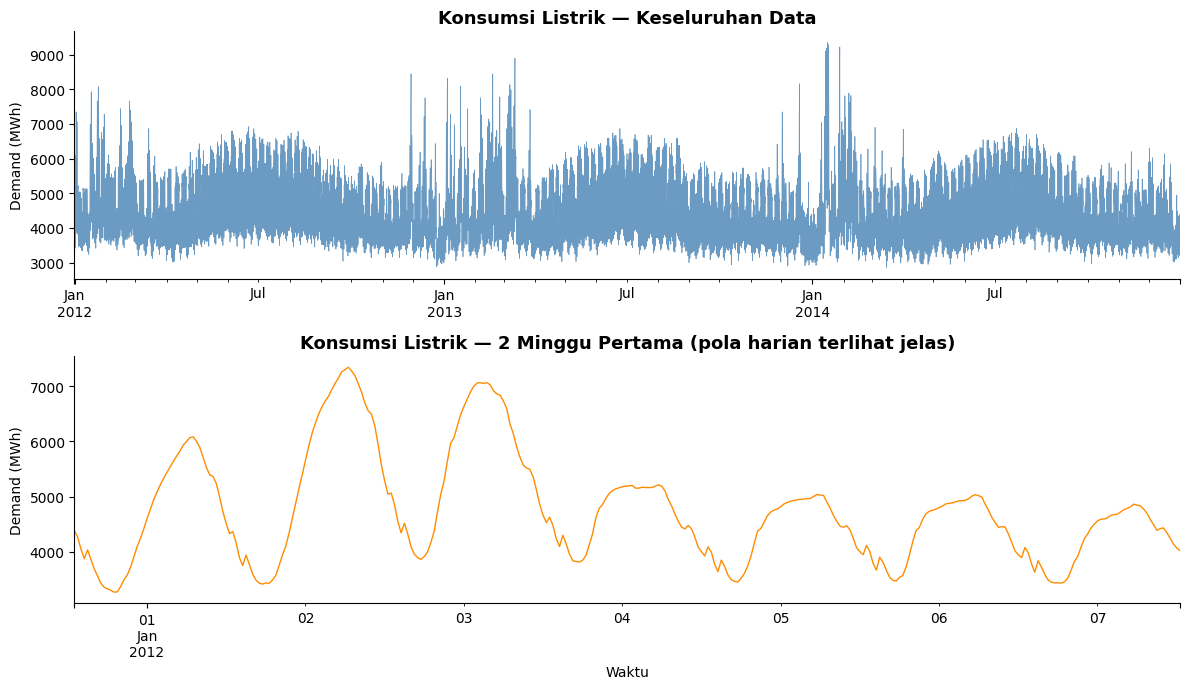

💡 Perhatikan pola naik-turun harian — ini yang akan ditangkap oleh lag!


In [8]:
# Visualisasi data — lihat 1 bulan pertama
fig, axes = plt.subplots(2, 1, figsize=(12, 7))

# Plot keseluruhan
data.plot(ax=axes[0], color='steelblue', linewidth=0.5, alpha=0.8)
axes[0].set_title('Konsumsi Listrik — Keseluruhan Data', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Demand (MWh)')
axes[0].set_xlabel('')

# Plot 2 minggu pertama (lebih detail)
data.iloc[:24*2*7].plot(ax=axes[1], color='darkorange', linewidth=1)
axes[1].set_title('Konsumsi Listrik — 2 Minggu Pertama (pola harian terlihat jelas)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Demand (MWh)')
axes[1].set_xlabel('Waktu')

plt.tight_layout()
plt.show()

print("💡 Perhatikan pola naik-turun harian — ini yang akan ditangkap oleh lag!")

 Step 4 — Memahami Konsep LAG
Lag adalah cara kita “memberi tahu” model tentang masa lalu.

Dengan lags=24, kita memberikan model:

lag_1 = nilai 30 menit yang lalu

lag_2 = nilai 1 jam yang lalu

lag_24 = nilai 12 jam yang lalu

Model belajar pola: “kalau 30 menit lalu konsumsi tinggi, kemungkinan sekarang juga masih tinggi”

In [9]:
# Ilustrasi manual bagaimana lag dibentuk
contoh = data.iloc[:6].copy()
df_lag = pd.DataFrame({
    'Waktu'   : contoh.index,
    'lag_3 (y_{t-3})': contoh.values,
    'lag_2 (y_{t-2})': contoh.shift(-1).values,
    'lag_1 (y_{t-1})': contoh.shift(-2).values,
    'TARGET y_t'     : contoh.shift(-3).values,
}).dropna()

print("📋 Contoh matriks training dengan lags=3:")
print()
print(df_lag.to_string(index=False))
print()
print("💡 Setiap baris = 1 sampel training.")
print("   Kolom lag_* = INPUT model")
print("   Kolom TARGET = yang harus diprediksi model")

📋 Contoh matriks training dengan lags=3:

                    Waktu  lag_3 (y_{t-3})  lag_2 (y_{t-2})  lag_1 (y_{t-1})  TARGET y_t
2011-12-31 13:00:00+00:00      4382.825174      4263.365526      4048.966046 3877.563330
2011-12-31 13:30:00+00:00      4263.365526      4048.966046      3877.563330 4036.229746
2011-12-31 14:00:00+00:00      4048.966046      3877.563330      4036.229746 3865.597244

💡 Setiap baris = 1 sampel training.
   Kolom lag_* = INPUT model
   Kolom TARGET = yang harus diprediksi model


Step 5 — Membuat dan Melatih Forecaster
Kita pakai ForecasterRecursive dengan:

Regressor: LGBMRegressor (LightGBM — model berbasis pohon, cepat dan akurat)

Lags: 24 (gunakan 24 langkah = 12 jam ke belakang)

In [ ]:
!pip uninstall -y skforecast
!pip install skforecast==0.15.1 --force-reinstall --no-cache-dir

import os
os.kill(os.getpid(), 9)

Found existing installation: skforecast 0.15.1
Uninstalling skforecast-0.15.1:
  Successfully uninstalled skforecast-0.15.1
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 6.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.7/58.7 kB 69.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 244.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 812.8/812.8 kB 27.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 309.1/309.1 kB 235.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 134.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 253.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 314.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 268.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 310.7/310.7 kB 338.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 284.6 MB/s eta 0:

In [4]:
from skforecast.recursive import ForecasterRecursive
from lightgbm import LGBMRegressor

In [5]:
# Membuat Forecaster
forecaster = ForecasterRecursive(
    regressor = LGBMRegressor(
        n_estimators  = 500,
        learning_rate = 0.05,
        max_depth     = 6,
        random_state  = 15926,
        verbose       = -1
    ),
    lags = 24
)

print("✅ Forecaster berhasil dibuat!")
print()
print(forecaster)

✅ Forecaster berhasil dibuat!

ForecasterRecursive 
Regressor: LGBMRegressor 
Lags: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24] 
Window features: None 
Window size: 24 
Exogenous included: False 
Exogenous names: None 
Transformer for y: None 
Transformer for exog: None 
Weight function included: False 
Differentiation order: None 
Training range: None 
Training index type: None 
Training index frequency: None 
Regressor parameters: 
    {'boosting_type': 'gbdt', 'class_weight': None, 'colsample_bytree': 1.0,
    'importance_type': 'split', 'learning_rate': 0.05, 'max_depth': 6,
    'min_child_samples': 20, 'min_child_weight': 0.001, 'min_split_gain': 0.0,
    'n_estimators': 500, 'n_jobs': None, 'num_leaves': 31, 'objective': None,
    'random_state': 15926, 'reg_alpha': 0.0, 'reg_lambda': 0.0, 'subsample':
    1.0, 'subsample_for_bin': 200000, 'subsample_freq': 0, 'verbose': -1} 
fit_kwargs: {} 
Creation date: 2026-06-11 07:32:02 
Last fit date: None 
Sk

In [8]:
print([x for x in globals().keys() if not x.startswith('_')])

['In', 'Out', 'get_ipython', 'exit', 'quit', 'skforecast', 'ForecasterRecursive', 'LGBMRegressor', 'forecaster']


In [9]:
import os
print(os.listdir())

['.config', 'sample_data']


In [30]:
print(data.columns)

Index(['Demand', 'Temperature', 'Date', 'Holiday'], dtype='str')


In [29]:
print(type(data))

<class 'pandas.DataFrame'>


In [33]:
# Latih (fit) model dengan seluruh data
print("⏳ Melatih model... (mungkin 10-30 detik)")

y = data['Demand']
forecaster.fit(y=y)

print("✅ Model selesai dilatih!")
print(f"   Jumlah lag yang digunakan : {forecaster.lags}")

⏳ Melatih model... (mungkin 10-30 detik)
✅ Model selesai dilatih!
   Jumlah lag yang digunakan : [1 2 3 4 5 6 7]


In [35]:
# Ambil kolom target sebagai Series
y = data['Demand']

# Ambil matriks training
X_train, y_train = forecaster.create_train_X_y(y=y)

print("📋 Matriks Training:")
print(f"   Shape X_train : {X_train.shape}  (baris=sampel, kolom=lag)")
print(f"   Shape y_train : {y_train.shape}")
print()
print("5 baris pertama X_train:")
print(X_train.head())

📋 Matriks Training:
   Shape X_train : (52601, 7)  (baris=sampel, kolom=lag)
   Shape y_train : (52601,)

5 baris pertama X_train:
                           lag_1        lag_2        lag_3        lag_4  \
Time                                                                      
2011-12-31 16:30:00  3694.097664  3865.597244  4036.229746  3877.563330   
2011-12-31 17:00:00  3561.623686  3694.097664  3865.597244  4036.229746   
2011-12-31 17:30:00  3433.035352  3561.623686  3694.097664  3865.597244   
2011-12-31 18:00:00  3359.468000  3433.035352  3561.623686  3694.097664   
2011-12-31 18:30:00  3331.343274  3359.468000  3433.035352  3561.623686   

                           lag_5        lag_6        lag_7  
Time                                                        
2011-12-31 16:30:00  4048.966046  4263.365526  4382.825174  
2011-12-31 17:00:00  3877.563330  4048.966046  4263.365526  
2011-12-31 17:30:00  4036.229746  3877.563330  4048.966046  
2011-12-31 18:00:00  3865.597244  4036

Step 6 — EXPLAINABILITY
Sekarang bagian utamanya! Kita akan menggunakan 4 teknik untuk memahami model.

6.1 — Feature Importance (Bawaan LightGBM)
Cara paling simpel: tanya langsung ke modelnya.
LightGBM menghitung seberapa sering tiap fitur dipakai untuk membelah (split) node di pohon keputusan.

  


In [36]:
# ============================================================================
# Feature Importance dari ForecasterRecursive
# ============================================================================
feat_imp = forecaster.get_feature_importances()
print("Top 10 fitur terpenting:")
print(feat_imp.head(10).to_string(index=False))

Top 10 fitur terpenting:
feature  importance
  lag_1         942
  lag_2         577
  lag_7         489
  lag_3         366
  lag_4         308
  lag_5         200
  lag_6         118


In [38]:
import matplotlib.pyplot as plt

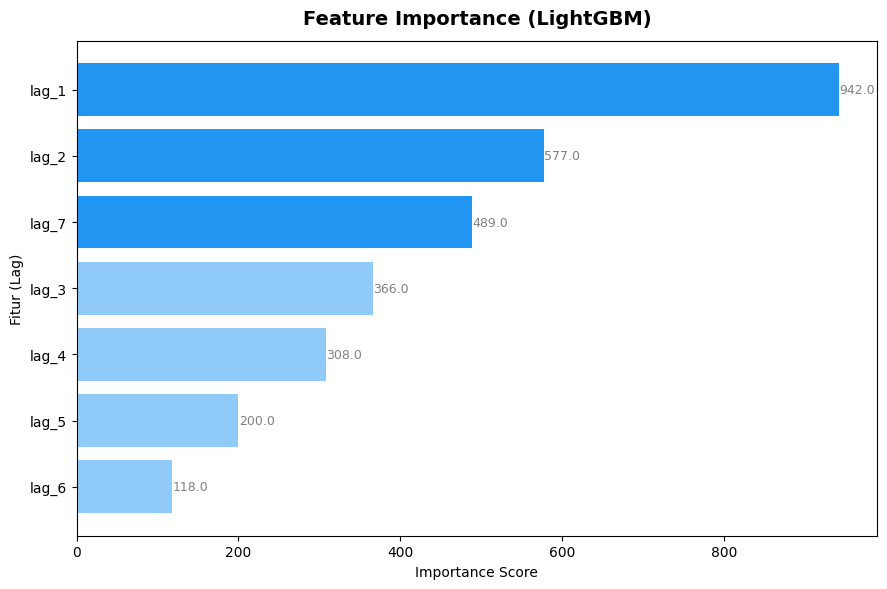

💡 lag_1 (30 menit lalu) = paling berpengaruh
   Makin besar lag → makin kecil pengaruhnya (wajar!)


In [39]:
# Visualisasi Feature Importance
fig, ax = plt.subplots(figsize=(9, 6))

# Sort dan ambil top 15
top = feat_imp.sort_values('importance', ascending=True).tail(15)

colors = ['#2196F3' if i >= len(top)-3 else '#90CAF9' for i in range(len(top))]
bars = ax.barh(top['feature'], top['importance'], color=colors, edgecolor='none')

ax.set_title('Feature Importance (LightGBM)', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Importance Score')
ax.set_ylabel('Fitur (Lag)')
ax.tick_params(axis='y', labelsize=10)

# Tambah label nilai di kanan bar
for bar in bars:
    w = bar.get_width()
    ax.text(w + 0.5, bar.get_y() + bar.get_height()/2,
            f'{w:.1f}', va='center', ha='left', fontsize=9, color='gray')

ax.annotate('← lag_1 paling penting!\n  (30 menit sebelumnya)',
            xy=(top['importance'].iloc[-1], 14),
            xytext=(top['importance'].max()*0.5, 11),
            arrowprops=dict(arrowstyle='->', color='red', lw=1.5),
            fontsize=9, color='red')

plt.tight_layout()
plt.show()

print("💡 lag_1 (30 menit lalu) = paling berpengaruh")
print("   Makin besar lag → makin kecil pengaruhnya (wajar!)")

6.2 — Permutation Importance
Ide dasarnya: “Kalau fitur ini tidak ada gunanya, mengacak nilainya tidak akan mempengaruhi model.”

Caranya:

Hitung error awal model

Acak satu fitur (misalnya lag_1)

Hitung error baru

Selisihnya = seberapa penting fitur itu

In [43]:
import pandas as pd

In [41]:
from sklearn.inspection import permutation_importance

In [44]:
# Permutation Importance
print("⏳ Menghitung permutation importance... (mungkin 1-2 menit)")

result = permutation_importance(
    estimator  = forecaster.regressor,
    X          = X_train,
    y          = y_train,
    n_repeats  = 10,     # diulangi 10 kali untuk stabilitas
    random_state = 123,
    n_jobs     = -1,     # pakai semua CPU
    scoring    = 'neg_mean_squared_error'
)

perm_df = pd.DataFrame({
    'feature'        : X_train.columns,
    'importance_mean': result.importances_mean,
    'importance_std' : result.importances_std
}).sort_values('importance_mean', ascending=False)

print("✅ Selesai! Top 10 fitur:")
print(perm_df.head(10).to_string(index=False))

⏳ Menghitung permutation importance... (mungkin 1-2 menit)
✅ Selesai! Top 10 fitur:
feature  importance_mean  importance_std
  lag_1     2.026651e+06     8052.748386
  lag_2     3.972131e+04      111.757156
  lag_3     5.097034e+03       42.496209
  lag_7     4.500701e+03       36.886330
  lag_4     4.410606e+03       40.223458
  lag_5     2.784745e+03       20.394006
  lag_6     7.959060e+02       11.241160


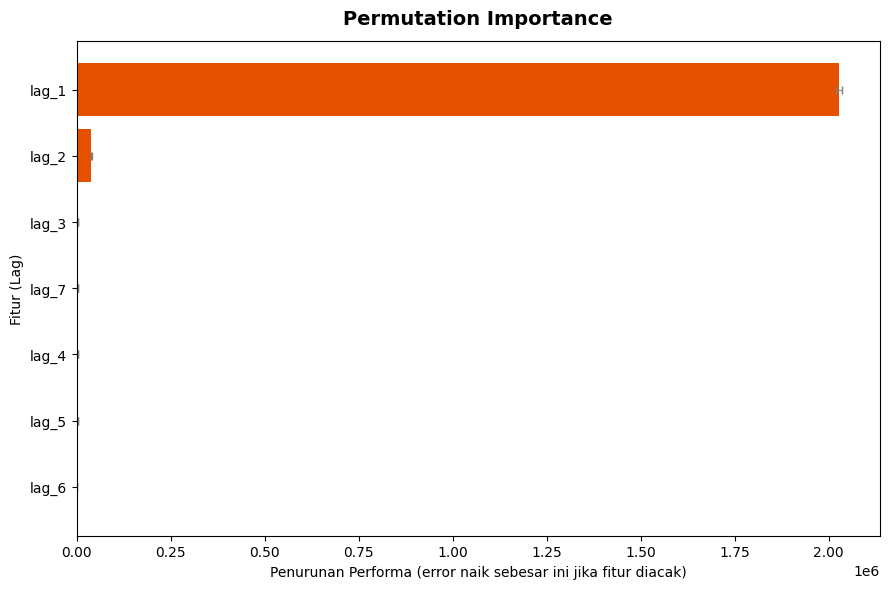

💡 Error bar menunjukkan variabilitas antar 10 kali pengulangan
   Semakin besar nilai = semakin penting fitur tersebut


In [45]:
# Visualisasi Permutation Importance
fig, ax = plt.subplots(figsize=(9, 6))

top_perm = perm_df.sort_values('importance_mean', ascending=True).tail(15)
colors_p = ['#E65100' if i >= len(top_perm)-3 else '#FFCC80' for i in range(len(top_perm))]

ax.barh(
    top_perm['feature'],
    top_perm['importance_mean'],
    xerr=top_perm['importance_std'],
    color=colors_p,
    capsize=3,
    edgecolor='none',
    error_kw={'ecolor': 'gray', 'elinewidth': 0.8}
)

ax.set_title('Permutation Importance', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Penurunan Performa (error naik sebesar ini jika fitur diacak)')
ax.set_ylabel('Fitur (Lag)')
ax.tick_params(axis='y', labelsize=10)

plt.tight_layout()
plt.show()

print("💡 Error bar menunjukkan variabilitas antar 10 kali pengulangan")
print("   Semakin besar nilai = semakin penting fitur tersebut")

6.3 — SHAP Values (SHapley Additive exPlanations)
Teknik paling canggih dan paling informatif. Setiap prediksi dipecah menjadi kontribusi masing-masing fitur:



  


  


  



Berbeda dengan feature importance yang global, SHAP bisa menjawab:

“Untuk prediksi pukul 14:00 hari Senin INI, kontribusi lag_1 adalah +200 MWh”

In [47]:
import shap

In [48]:
# Hitung SHAP Values menggunakan TreeExplainer
# (TreeExplainer khusus untuk model berbasis pohon seperti LightGBM)
print("⏳ Menghitung SHAP values... (mungkin 1-2 menit)")

shap.initjs()  # inisialisasi JavaScript untuk visualisasi interaktif

explainer   = shap.TreeExplainer(forecaster.regressor)
shap_values = explainer.shap_values(X_train)

print(f"✅ SHAP values berhasil dihitung!")
print(f"   Shape: {shap_values.shape}")
print(f"   Artinya: {shap_values.shape[0]:,} observasi × {shap_values.shape[1]} fitur")
print(f"   Baseline (rata-rata prediksi): {explainer.expected_value:.2f} MWh")

⏳ Menghitung SHAP values... (mungkin 1-2 menit)


✅ SHAP values berhasil dihitung!
   Shape: (52601, 7)
   Artinya: 52,601 observasi × 7 fitur
   Baseline (rata-rata prediksi): 4665.52 MWh


In [50]:
import numpy as np

📊 SHAP Summary Plot — kontribusi semua fitur:



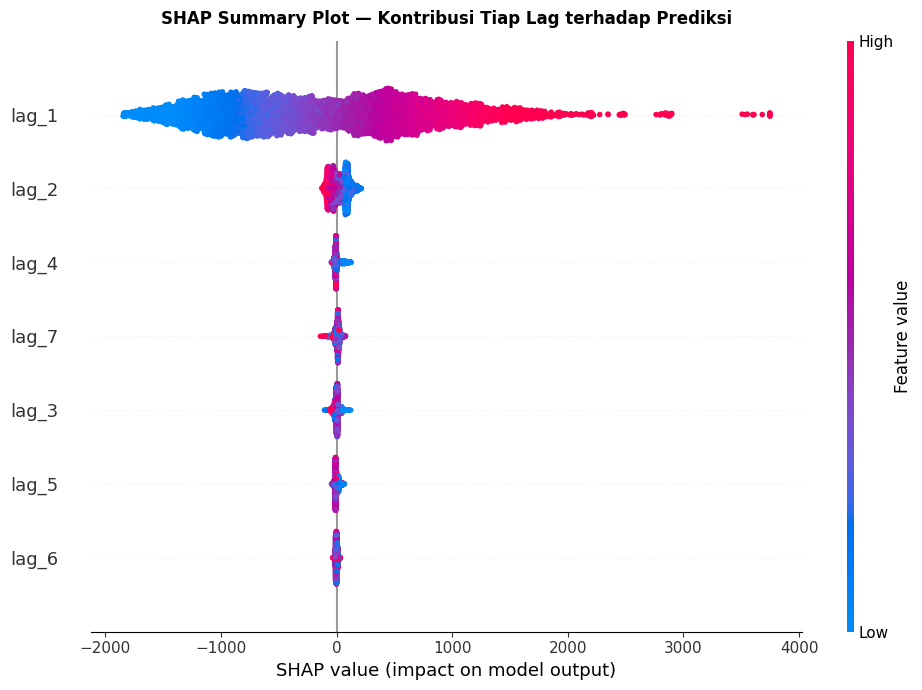

💡 Cara baca:
   Titik merah di kanan  = nilai lag tinggi → mendorong prediksi NAIK
   Titik biru di kiri    = nilai lag rendah → mendorong prediksi TURUN
   Fitur di atas lebih berpengaruh daripada yang di bawah


In [51]:
# SHAP Summary Plot (Beeswarm) — gambaran besar
# Cara baca:
#   - Sumbu X = nilai SHAP (positif = mendorong prediksi NAIK)
#   - Warna titik = nilai fitur asli (merah=tinggi, biru=rendah)
#   - Tiap titik = satu observasi/prediksi
# ============================================================================
print("📊 SHAP Summary Plot — kontribusi semua fitur:")
print()

# Gunakan subset agar lebih cepat (5000 sampel acak)
idx = np.random.choice(len(X_train), 5000, replace=False)

fig, ax = plt.subplots(figsize=(10, 7))
shap.summary_plot(
    shap_values[idx],
    X_train.iloc[idx],
    max_display=24,
    show=False,
    plot_size=None
)
plt.title('SHAP Summary Plot — Kontribusi Tiap Lag terhadap Prediksi',
          fontsize=12, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

print("💡 Cara baca:")
print("   Titik merah di kanan  = nilai lag tinggi → mendorong prediksi NAIK")
print("   Titik biru di kiri    = nilai lag rendah → mendorong prediksi TURUN")
print("   Fitur di atas lebih berpengaruh daripada yang di bawah")

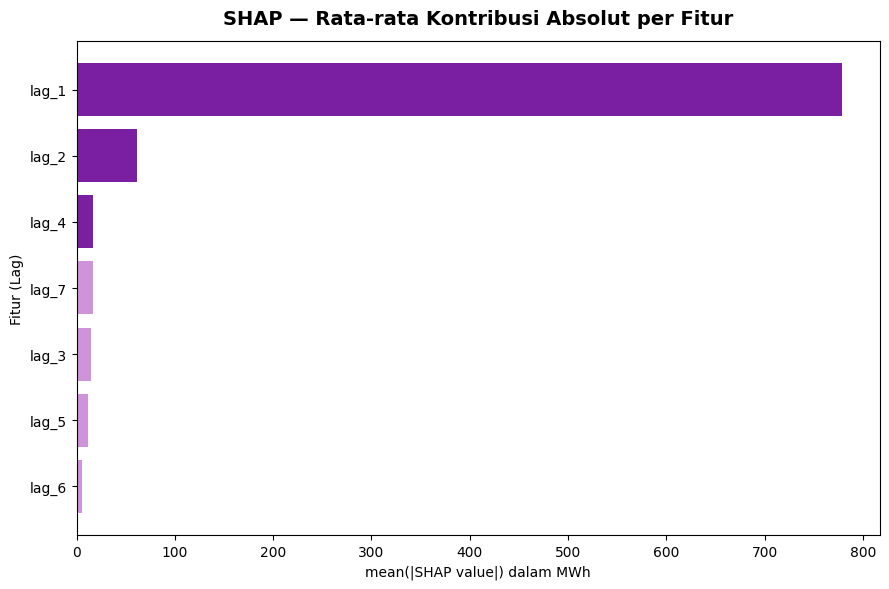

💡 Nilai ini berarti 'rata-rata, fitur ini mempengaruhi prediksi sebesar X MWh'


In [52]:
# SHAP Bar Plot — rata-rata kontribusi absolut
mean_shap = np.abs(shap_values).mean(axis=0)
shap_df = pd.DataFrame({
    'feature'   : X_train.columns,
    'mean_shap' : mean_shap
}).sort_values('mean_shap', ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))
colors_s = ['#7B1FA2' if i >= len(shap_df)-3 else '#CE93D8' for i in range(len(shap_df))]
ax.barh(shap_df['feature'], shap_df['mean_shap'], color=colors_s, edgecolor='none')
ax.set_title('SHAP — Rata-rata Kontribusi Absolut per Fitur', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('mean(|SHAP value|) dalam MWh')
ax.set_ylabel('Fitur (Lag)')
plt.tight_layout()
plt.show()

print("💡 Nilai ini berarti 'rata-rata, fitur ini mempengaruhi prediksi sebesar X MWh'")

🔍 Penjelasan untuk prediksi ke-100:
   Waktu      : 2012-01-02 18:30:00
   Nilai aktual: 4000.2 MWh
   Baseline    : 4665.5 MWh

   Top 5 kontributor:
   lag_1    =   3913.9 MWh  →  kontribusi -806.7 MWh (↓ turun)
   lag_2    =   3863.8 MWh  →  kontribusi +138.8 MWh (↑ naik)
   lag_7    =   4518.9 MWh  →  kontribusi +16.5 MWh (↑ naik)
   lag_3    =   3896.5 MWh  →  kontribusi -10.7 MWh (↓ turun)
   lag_4    =   3959.5 MWh  →  kontribusi +9.0 MWh (↑ naik)

📊 Force Plot (tampilkan dengan shap.initjs() di Colab):


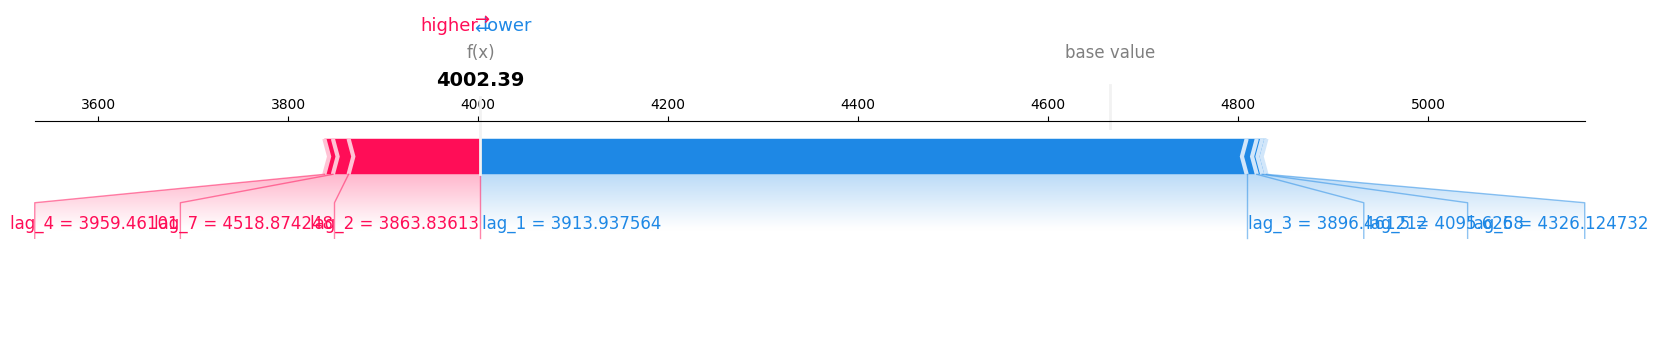

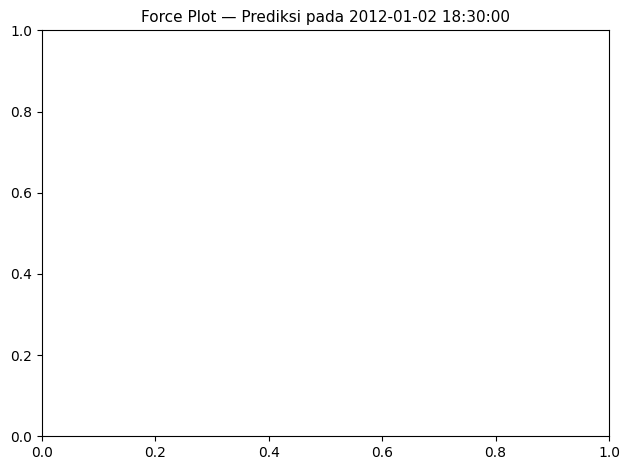

In [53]:
# SHAP Force Plot — penjelasan untuk SATU prediksi spesifik
idx_contoh = 100

print(f"🔍 Penjelasan untuk prediksi ke-{idx_contoh}:")
print(f"   Waktu      : {X_train.index[idx_contoh]}")
print(f"   Nilai aktual: {y_train.iloc[idx_contoh]:.1f} MWh")
print(f"   Baseline    : {explainer.expected_value:.1f} MWh")
print()

# Tampilkan 5 kontributor terbesar
contribs = pd.DataFrame({
    'fitur' : X_train.columns,
    'nilai_fitur': X_train.iloc[idx_contoh].values,
    'shap_value' : shap_values[idx_contoh]
}).sort_values('shap_value', key=abs, ascending=False)

print("   Top 5 kontributor:")
for _, row in contribs.head(5).iterrows():
    tanda = '+' if row['shap_value'] > 0 else ''
    arah  = '↑ naik' if row['shap_value'] > 0 else '↓ turun'
    print(f"   {row['fitur']:8s} = {row['nilai_fitur']:8.1f} MWh  →  kontribusi {tanda}{row['shap_value']:.1f} MWh ({arah})")

print()
print("📊 Force Plot (tampilkan dengan shap.initjs() di Colab):")

# Force plot
shap.force_plot(
    explainer.expected_value,
    shap_values[idx_contoh, :],
    X_train.iloc[idx_contoh, :],
    matplotlib=True
)
plt.title(f'Force Plot — Prediksi pada {X_train.index[idx_contoh]}', fontsize=11)
plt.tight_layout()
plt.show()

In [55]:
print(X_train.columns.tolist())

['lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_5', 'lag_6', 'lag_7']


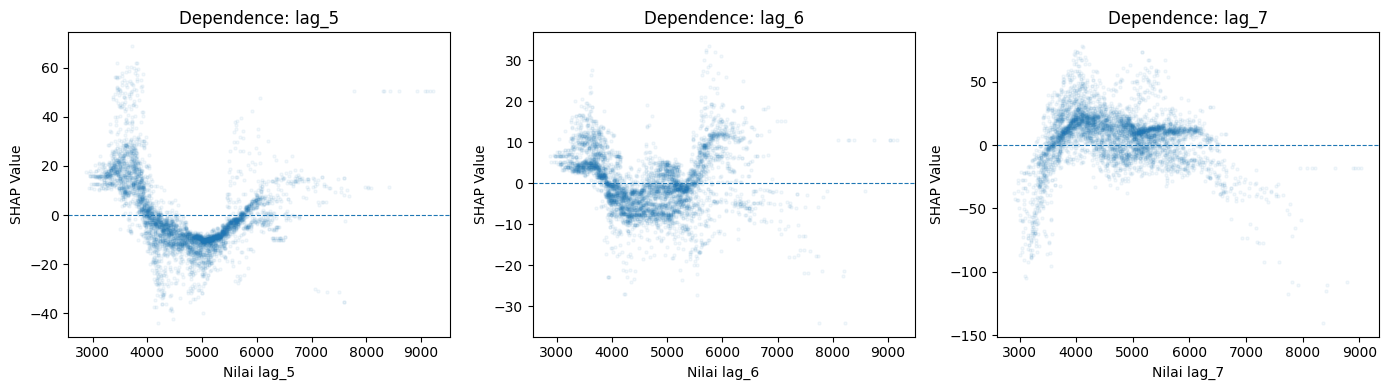

✅ SHAP Dependence Plot berhasil dibuat


In [58]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Ambil 3 kolom terakhir yang pasti ada
fitur = X_train.columns[-3:]

for ax, feat in zip(axes, fitur):
    feat_idx = list(X_train.columns).index(feat)

    ax.scatter(
        X_train.iloc[idx, feat_idx],
        shap_values[idx, feat_idx],
        alpha=0.05,
        s=5
    )

    ax.axhline(0, linestyle='--', linewidth=0.8)
    ax.set_xlabel(f'Nilai {feat}')
    ax.set_ylabel('SHAP Value')
    ax.set_title(f'Dependence: {feat}')

plt.tight_layout()
plt.show()

print("✅ SHAP Dependence Plot berhasil dibuat")

6.4 — Partial Dependence Plot (PDP)
PDP menunjukkan hubungan rata-rata antara satu fitur dan output prediksi, sambil menganggap fitur lain konstan.



Intinya: “Kalau saya ubah-ubah lag_1, rata-rata prediksinya seperti apa?”

⏳ Menghitung PDP.. (mungkin 30-60 detik)


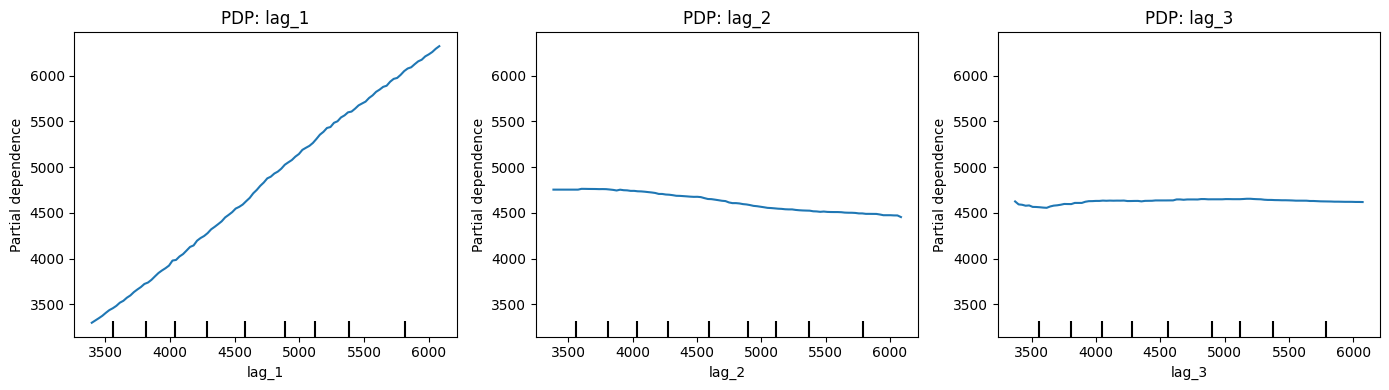

✅ Selesai!


In [60]:
from sklearn.inspection import PartialDependenceDisplay
import numpy as np
import matplotlib.pyplot as plt

print("⏳ Menghitung PDP.. (mungkin 30-60 detik)")

# Ambil 3 fitur pertama yang tersedia
features_pdp = list(X_train.columns[:3])
feat_indices = [X_train.columns.get_loc(f) for f in features_pdp]

# Gunakan subset agar lebih cepat
n_sample = min(2000, len(X_train))
random_idx = np.random.choice(len(X_train), n_sample, replace=False)
X_sub = X_train.iloc[random_idx]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

PartialDependenceDisplay.from_estimator(
    estimator=forecaster.regressor,
    X=X_sub,
    features=feat_indices,
    feature_names=list(X_train.columns),
    ax=axes
)

for ax, feat in zip(axes, features_pdp):
    ax.set_title(f'PDP: {feat}')

plt.tight_layout()
plt.show()

print("✅ Selesai!")

Kesimpulan
Nilai konsumsi 30 menit yang lalu (lag_1) = paling berpengaruh

Pola harian (lag 24-48) juga signifikan

Model tidak sekadar blackbox — bisa dijelaskan dengan baik

SHAP adalah teknik paling informatif: bisa lihat pengaruh per prediksi

